# Saharan Dust Episode of 3-4 March 2026: Analysis Using AERONET Data at Four Stations in the Iberian Peninsula

Due to the amount of clouds present those dates, only 5 station in the Iberian peninsula had data from both dates

<a href="https://colab.research.google.com/github/jrobrien91/agora2026-dust/blob/main/notebooks/AERONET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](../images/MODIS_0432026.png)

We selected 4 of them: Cabo da Roca, Evora, Badajoz, Majadas

![](../images/stations.png)

First we need to import the required libraries

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import dates
import numpy as np

## Aerosol Optical Depth (AOD) and Ångström Exponent

Sun photometers measure the incident direct solar radiation that reaches the surface at different wavelengths ($E_{\lambda}$). This radiation is attenuated by particles in the atmosphere, which include gases and aerosols. Clouds are excluded from the dataset due to the extremely high attenuation they exert over direct radiation.

By knowing the extraterrestrial solar radiation ($E_{0, \lambda}$) at the Top of the Atmosphere (TOA) and the solar path the radiation takes through the atmosphere (air mass, $m$), we can determine how much the solar radiation has been attenuated using the Beer-Lambert-Bouguer law:

$$E_{\lambda} = E_{0, \lambda} \cdot \exp[-m \cdot \tau]$$

The total optical depth ($\tau$) in the absence of clouds is given as the sum of its components: 

$$\tau = \tau_{gas} + \tau_{Rayleigh} + \tau_{aerosols}$$

Hence, isolating the aerosol component, the AOD can be computed as: 

$$AOD_{\lambda} = \tau_{aerosols, \lambda} = \frac{1}{m} \cdot \ln\left(\frac{E_{0, \lambda}}{E_{\lambda}}\right) - \tau_{Rayleigh, \lambda} - \tau_{gas, \lambda}$$


The empirical Ångström Law parameterizes the AOD spectral dependence as: 

$$AOD_{\lambda} = \beta \cdot \lambda^{-\alpha}$$

where $\beta$ is the AOD at $1\mu m$ (1000 nm), and $\alpha$ (the Ångström exponent) describes how the AOD varies with the wavelength.

*Majadas and Évora are equipped with the new generation of CIMEL photometers, enabling the inclusion of lunar AOD measurements for nighttime retrievals.*

In [ ]:
# Uncomment if running on CoLab
##import pathlib
##from pathlib import Path
##import gdown

##DATA_LINK = "1xUbEhD5dmhx8zunkEFD9JI2oXlsm-hno"
##CREATE_BASE = pathlib.Path("./sample_data")
##CREATE_BASE.mkdir(parents=True, exist_ok=True)
##gdown.download(id=DATA_LINK, output=str(CREATE_BASE / "aeronet.zip"), quiet=False)

In [ ]:
# Uncomment if running on Colab
#!unzip ./sample_data/aeronet.zip

In [59]:
# Day data
df_cabo = pd.read_csv('data/aod/day/20260301_20260330_Cabo_da_Roca.lev15', sep=',', skiprows=6, na_values=-999)
df_evora_day = pd.read_csv('data/aod/day/20260301_20260330_Evora.lev15', sep=',', skiprows=6, na_values=-999)
df_majadas_day = pd.read_csv('data/aod/day/20260301_20260330_Majadas.lev15', sep=',', skiprows=6, na_values=-999)
df_badajoz = pd.read_csv('data/aod/day/20260301_20260331_Badajoz.lev15', sep=',', skiprows=6, na_values=-999, encoding='latin1')

# Night Data
df_evora_night = pd.read_csv('data/aod/night/20260301_20260331_Evora.lev15', sep=',', skiprows=6, na_values=-999)
df_majadas_night = pd.read_csv('data/aod/night/20260301_20260331_Majadas.lev15', sep=',', skiprows=6, na_values=-999)

We need to create the datetime column in order to sort data temporally and we concatenate the day and night dataframes

In [96]:
dfs = [df_cabo, df_evora_day, df_majadas_day, df_badajoz, df_evora_night, df_majadas_night]

for _,df in enumerate(dfs):

    df['time'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format = '%d:%m:%Y %H:%M:%S')
    df.set_index('time', inplace=True)

df_evora   = pd.concat([df_evora_day,df_evora_night]).sort_index()
df_majadas = pd.concat([df_majadas_day,df_majadas_night]).sort_index()

dfs = [df_cabo, df_evora, df_badajoz, df_majadas]
dfs_titles = ['Cabo da Roca', 'Évora', 'Badajoz', 'Majadas']

We define a function to plot everything (only in the 3-5 of march)

In [97]:
def plot(df, list_columns, title, y_label, ymin, ymax, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4), layout='constrained')

    df_filt = df.loc['2026-03-02':'2026-03-05']

    for column in list_columns:
        ax.plot(df_filt.index, df_filt[column], marker='o', linestyle='--', linewidth=1, markersize=5, label=column)

    ax.set_title(title, fontsize=20)
    ax.set_ylabel(y_label, fontsize=18) 
    ax.set_xlabel('Time (DD-hh)', fontsize=18) 
    ax.legend(fontsize=12, loc="best", edgecolor='k')
    ax.set_ylim(ymin=ymin, ymax=ymax)
    ax.grid(linestyle='--')

    date_format = dates.DateFormatter('%d %Hh')
    ax.xaxis.set_major_formatter(date_format)
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    return ax

We plot AOD and Angtröm Exponent at the 4 places in the same figure

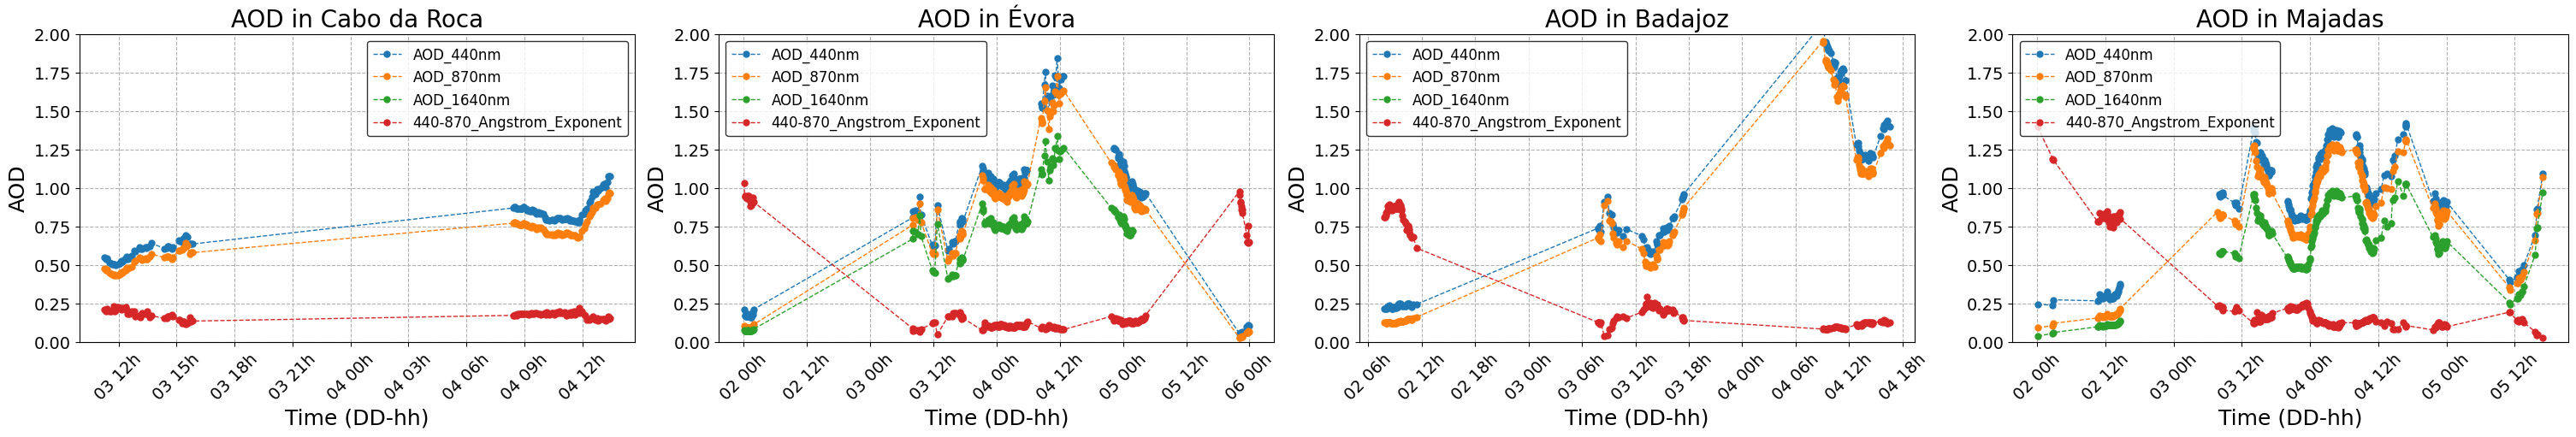

In [98]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(30, 5), layout='constrained')

for ii, df in enumerate(dfs):

    plot(df, list_columns=['AOD_440nm', 'AOD_870nm', 'AOD_1640nm', '440-870_Angstrom_Exponent'], title=f'AOD in {dfs_titles[ii]}', y_label='AOD', ymin=0, ymax=2, ax=axes[ii])

plt.show()

Regarding the spatial distribution of the event, Évora and Badajoz presented the highest AOD among the four sites, reaching peak values close to 2.0. Majadas (located further north) and Cabo da Roca did not reach those maximums, but still registered an extreme event with AOD values near 1.25 and 1.00, respectively. According to the Évora data, the dust intrusion ended by March 6th (the rest of the stations lack data for the following week due to cloud screening).

The low values of the Ångström exponent (around 0.2) indicate a weak dependence of the optical depth on the wavelength. This is a typical optical signature of coarse desert dust particles, which is visually supported by the AOD lines in the graph: the values for 440 nm, 870 nm, and 1640 nm remain very to each other during the peak of the episode.

## SSA and Asymetry factor

AERONET also performs inversions using sky radiances measured in the almucantar or hybrid planes. 

These are the properties retrieved from the inversions, which are needed to run the RT forward model and which most significantly affect the Aerosol Radiative Forcing (ARF):

* **Single Scattering Albedo** ($SSA = \frac{\sigma_{s}}{\sigma_{s}+\sigma_{a}}$, where $\sigma$ are the scattering and absorption coefficients): is the proportion of total light extinction that is due to scattering.

* **Asymmetry Factor** ($g$): represents the average of the cosine of the scattering angle. 

Surface albedo also has a great impact on the RT model. AERONET retrieves surface albedo data from satellite observations.

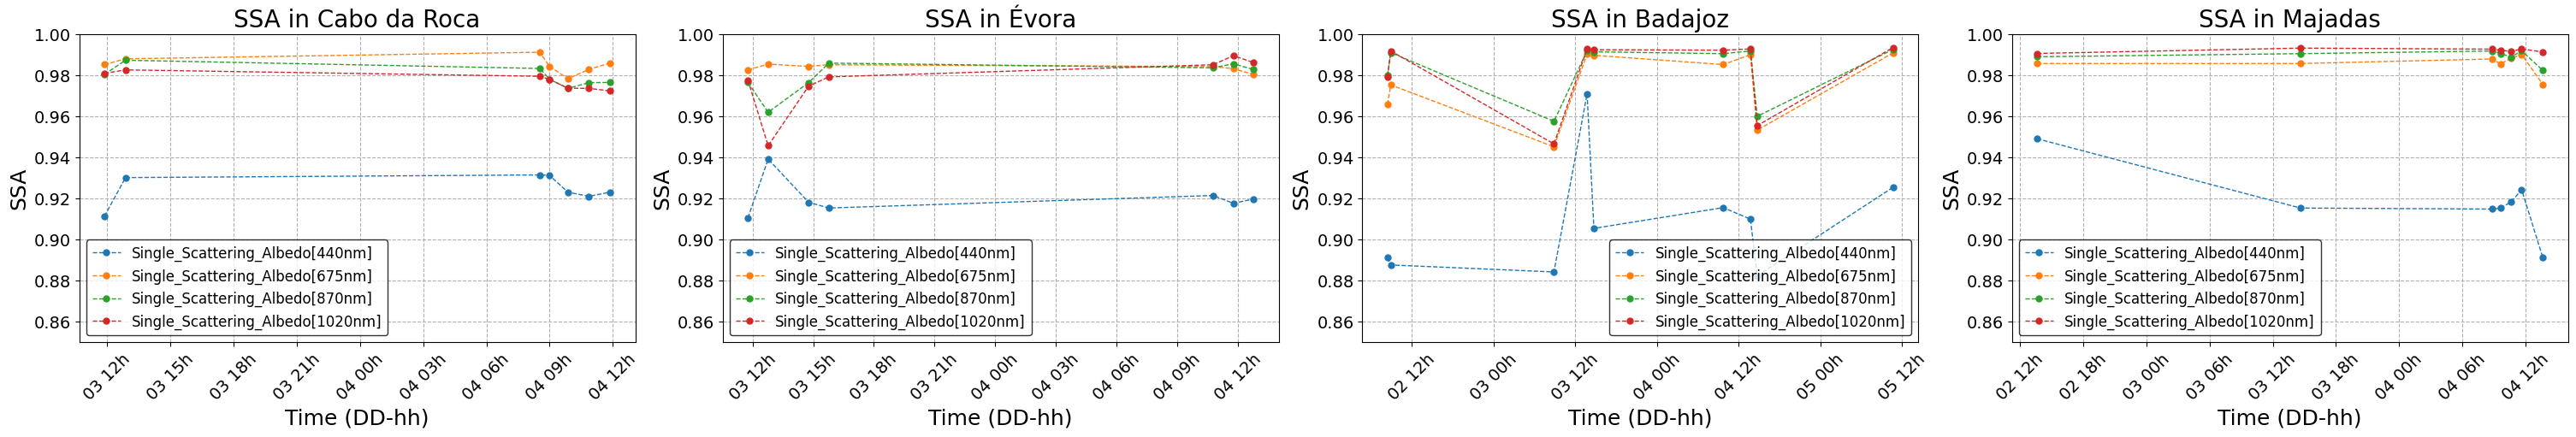

In [100]:
df_SSA_cabo = pd.read_csv('./data/inversions/20260301_20260330_Cabo_da_Roca/20260301_20260330_Cabo_da_Roca.ssa', sep=',', skiprows=6, na_values=-999)
df_SSA_evora = pd.read_csv('./data/inversions/20260301_20260330_Evora/20260301_20260330_Evora.ssa', sep=',', skiprows=6, na_values=-999)
df_SSA_majadas = pd.read_csv('./data/inversions/20260301_20260330_Majadas/20260301_20260330_Majadas.ssa', sep=',', skiprows=6, na_values=-999)
df_SSA_badajoz = pd.read_csv('./data/inversions/20260301_20260330_Badajoz/20260301_20260330_Badajoz.ssa', sep=',', skiprows=6, na_values=-999, encoding='latin1')

dfs_SSA = [df_SSA_cabo, df_SSA_evora, df_SSA_badajoz, df_SSA_majadas]

for _,df in enumerate(dfs_SSA):
    
    df['time'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format = '%d:%m:%Y %H:%M:%S')
    df.set_index('time', inplace=True)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(30, 5), layout='constrained')

for ii, df in enumerate(dfs_SSA):

    plot(df, list_columns=['Single_Scattering_Albedo[440nm]', 'Single_Scattering_Albedo[675nm]', 'Single_Scattering_Albedo[870nm]', 'Single_Scattering_Albedo[1020nm]'], title=f'SSA in {dfs_titles[ii]}', y_label='SSA', ymin=0.85, ymax=1, ax=axes[ii])

plt.show()

The retrieved SSA reveals a highly absorving Aerosol near the visible shortwave wavelengths while a high scattering in larger wavelengths, which again is typical of the chemical composition of dust

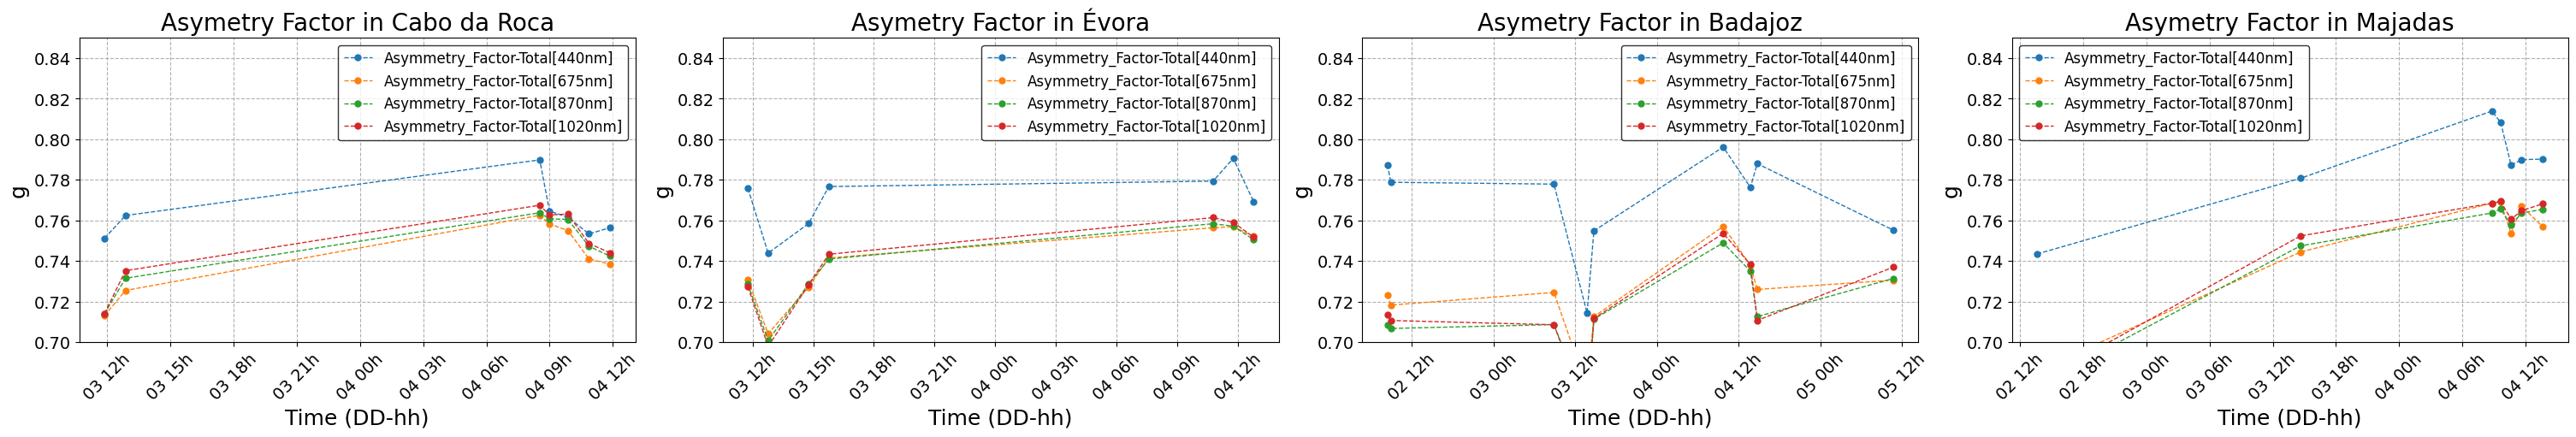

In [101]:
df_asy_cabo = pd.read_csv('./data/inversions/20260301_20260330_Cabo_da_Roca/20260301_20260330_Cabo_da_Roca.asy', sep=',', skiprows=6, na_values=-999)
df_asy_evora = pd.read_csv('./data/inversions/20260301_20260330_Evora/20260301_20260330_Evora.asy', sep=',', skiprows=6, na_values=-999)
df_asy_majadas = pd.read_csv('./data/inversions/20260301_20260330_Majadas/20260301_20260330_Majadas.asy', sep=',', skiprows=6, na_values=-999)
df_asy_badajoz = pd.read_csv('./data/inversions/20260301_20260330_Badajoz/20260301_20260330_Badajoz.asy', sep=',', skiprows=6, na_values=-999, encoding='latin1')

dfs_asy = [df_asy_cabo, df_asy_evora, df_asy_badajoz, df_asy_majadas]

for _,df in enumerate(dfs_asy):
    
    df['time'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format = '%d:%m:%Y %H:%M:%S')
    df.set_index('time', inplace=True)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(30, 5), layout='constrained')

for ii, df in enumerate(dfs_asy):

    plot(df, list_columns=['Asymmetry_Factor-Total[440nm]', 'Asymmetry_Factor-Total[675nm]', 'Asymmetry_Factor-Total[870nm]', 'Asymmetry_Factor-Total[1020nm]'], title=f'Asymetry Factor in {dfs_titles[ii]}', y_label='g', ymin=0.7, ymax=0.85, ax=axes[ii])

plt.show()

The values are in general above 0.7 which confirms that the main scaterring direction is the forward one (Mie Scattering).

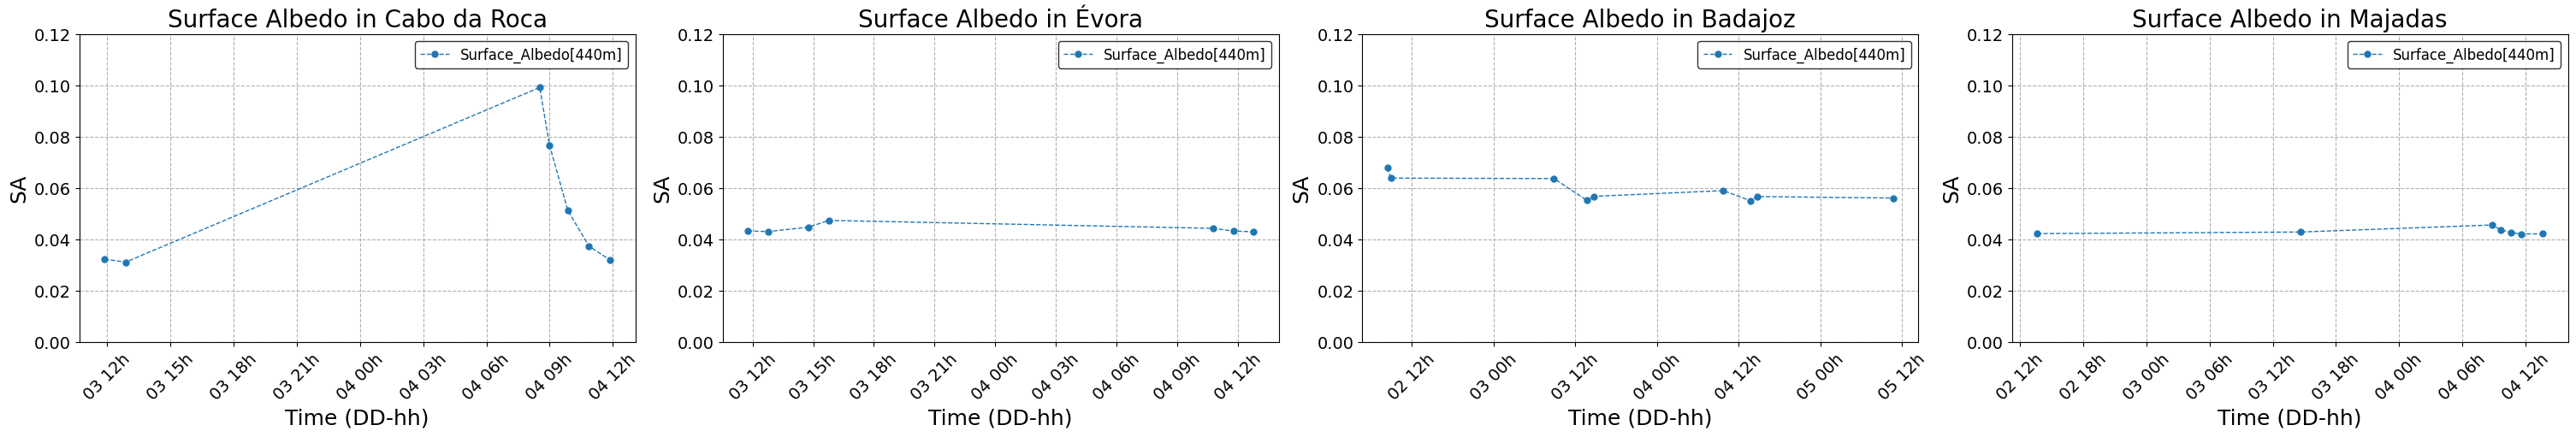

In [102]:
df_frc_cabo = pd.read_csv('./data/inversions/20260301_20260330_Cabo_da_Roca/20260301_20260330_Cabo_da_Roca.frc', sep=',', skiprows=6, na_values=-999)
df_frc_evora = pd.read_csv('./data/inversions/20260301_20260330_Evora/20260301_20260330_Evora.frc', sep=',', skiprows=6, na_values=-999)
df_frc_majadas = pd.read_csv('./data/inversions/20260301_20260330_Majadas/20260301_20260330_Majadas.frc', sep=',', skiprows=6, na_values=-999)
df_frc_badajoz = pd.read_csv('./data/inversions/20260301_20260330_Badajoz/20260301_20260330_Badajoz.frc', sep=',', skiprows=6, na_values=-999, encoding='latin1')

dfs_frc = [df_frc_cabo, df_frc_evora, df_frc_badajoz, df_frc_majadas]

for _,df in enumerate(dfs_frc):
    
    df['time'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format = '%d:%m:%Y %H:%M:%S')
    df.set_index('time', inplace=True)

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(30, 5), layout='constrained')

for ii, df in enumerate(dfs_asy):

    plot(df, list_columns=['Surface_Albedo[440m]'], title=f'Surface Albedo in {dfs_titles[ii]}', y_label='SA', ymin=0., ymax=0.12, ax=axes[ii])

plt.show()

## Aerosol Radiative Forcing and Forcing efficiency

By simulating a clean, aerosol-free atmosphere and comparing it with a simulated atmosphere containing the retrieved aerosol parameters, AERONET evaluates the forcing of the aerosol on the Earth's radiative balance. 

This Aerosol Radiative Forcing (ARF) can be calculated at the surface (Bottom of Atmosphere, BOA) to determine if the aerosol warms or cools the ground, within the atmosphere (ATM) to evaluate the heating or cooling of the air mass, and at the Top of Atmosphere (TOA) to assess the overall impact on the Earth's climate system.

In addition, the Radiative Forcing Efficiency ($F_{eff}$) can be calculated, which quantifies the forcing effect produced per unit of Aerosol Optical Depth (AOD).

Now we need to re-write the plotting function as we need to calculate some linear fits in order to find the efficiency

In [121]:
color = ['blue', 'orange', 'green']

def plot_frc(df, aod_column, list_ARE, title, y_label, ymin, ymax, ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(8,4), layout='constrained')

    df_filt = df.loc['2026-03-02':'2026-03-05']
    df_filt = df_filt[df_filt['Coincident_AOD440nm'] > 0.5]
    df_filt = df_filt[df_filt['440-870_Angstrom_Exponent'] < 0.25]

    for ii, column in enumerate(list_ARE):
        error = np.abs(df_filt[column]*(df_filt['Sky_Residual(%)']/100))
        ax.errorbar(df_filt[aod_column], df_filt[column], yerr=error, fmt='o', color=color[ii], alpha=0.8, ecolor='black', label=column, elinewidth=1.5, capsize=4)
        
        z = np.polyfit(df_filt[aod_column], df_filt[column], 1)
        p = np.poly1d(z)
        slope = z[0]
            
        ax.plot(df_filt[aod_column], p(df_filt[aod_column]), color=color[ii], linestyle='--', label=f"Efficiency: {slope:.2f} W/m²" )

    ax.set_title(title, fontsize=20)
    ax.set_ylabel(y_label, fontsize=18) 
    ax.set_xlabel('AOD', fontsize=18) 
    ax.legend(fontsize=12, loc="best", edgecolor='k')
    ax.set_ylim(ymin=ymin, ymax=ymax)
    ax.grid(linestyle='--')
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    
    return ax

We merge tables to filter data by angstrom exponent too

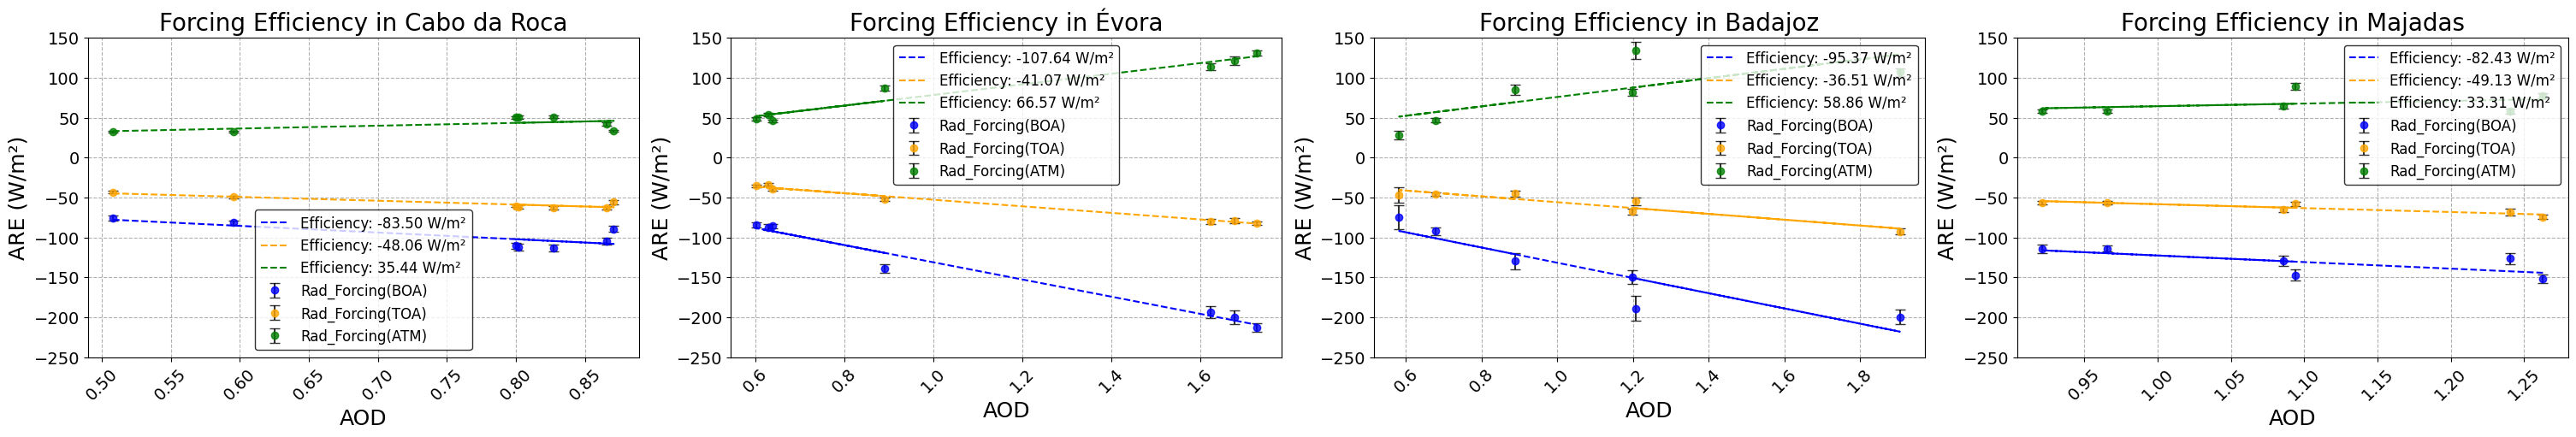

In [ ]:
df_frc_cabo = pd.read_csv('./data/inversions/20260301_20260330_Cabo_da_Roca/20260301_20260330_Cabo_da_Roca.frc', sep=',', skiprows=6, na_values=-999)
df_frc_evora = pd.read_csv('./data/inversions/20260301_20260330_Evora/20260301_20260330_Evora.frc', sep=',', skiprows=6, na_values=-999)
df_frc_majadas = pd.read_csv('./data/inversions/20260301_20260330_Majadas/20260301_20260330_Majadas.frc', sep=',', skiprows=6, na_values=-999)
df_frc_badajoz = pd.read_csv('./data/inversions/20260301_20260330_Badajoz/20260301_20260330_Badajoz.frc', sep=',', skiprows=6, na_values=-999, encoding='latin1')

dfs_frc_raw = [df_frc_cabo, df_frc_evora, df_frc_badajoz, df_frc_majadas]

for df in dfs_frc_raw:
    df['time'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'], format='%d:%m:%Y %H:%M:%S')
    df.set_index('time', inplace=True)
    df['Rad_Forcing(ATM)'] = df['Rad_Forcing(TOA)'] - df['Rad_Forcing(BOA)']

df_frc_cabo.sort_index(inplace=True)
df_cabo.sort_index(inplace=True)

df_frc_evora.sort_index(inplace=True)
df_evora.sort_index(inplace=True)

df_frc_badajoz.sort_index(inplace=True)
df_badajoz.sort_index(inplace=True)

df_frc_majadas.sort_index(inplace=True)
df_majadas.sort_index(inplace=True)

tolerance = pd.Timedelta('15min')

df_frc_cabo = pd.merge_asof(df_frc_cabo, df_cabo[['440-870_Angstrom_Exponent']], 
                            left_index=True, right_index=True, direction='nearest', tolerance=tolerance)

df_frc_evora = pd.merge_asof(df_frc_evora, df_evora[['440-870_Angstrom_Exponent']], 
                             left_index=True, right_index=True, direction='nearest', tolerance=tolerance)

df_frc_badajoz = pd.merge_asof(df_frc_badajoz, df_badajoz[['440-870_Angstrom_Exponent']], 
                               left_index=True, right_index=True, direction='nearest', tolerance=tolerance)

df_frc_majadas = pd.merge_asof(df_frc_majadas, df_majadas[['440-870_Angstrom_Exponent']], 
                               left_index=True, right_index=True, direction='nearest', tolerance=tolerance)

df_frc_cabo.dropna(subset=['440-870_Angstrom_Exponent'], inplace=True)
df_frc_evora.dropna(subset=['440-870_Angstrom_Exponent'], inplace=True)
df_frc_badajoz.dropna(subset=['440-870_Angstrom_Exponent'], inplace=True)
df_frc_majadas.dropna(subset=['440-870_Angstrom_Exponent'], inplace=True)


dfs_frc = [df_frc_cabo, df_frc_evora, df_frc_badajoz, df_frc_majadas]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(30, 5), layout='constrained')

for ii, df in enumerate(dfs_frc):

    plot_frc(df, aod_column='Coincident_AOD440nm', list_ARE=['Rad_Forcing(BOA)', 'Rad_Forcing(TOA)', 'Rad_Forcing(ATM)'], title=f'Forcing Efficiency in {dfs_titles[ii]}', y_label='ARE (W/m²)', ymin=-250, ymax=+150, ax=axes[ii])

plt.show()


| Site | BOA ($W/m^2$) | TOA ($W/m^2$) | ATM ($W/m^2$) |
| :--- | :---: | :---: | :---: |
| **Cabo da Roca** | -83.50 | -48.06 | 35.44 |
| **Évora** | -107.64 | -41.07 | 66.57 |
| **Badajoz** | -95.54 | -36.54 | 59.00 |
| **Majadas** | -82.43 | -49.13 | 33.31 |

- All stations exhibit a strong negative efficiency at BOA, ranging from -82.43 to -107.64 $W/m^2$. This translates to a significant reduction in the direct solar radiation reaching the ground, inducing a significant surface cooling effect.
- At the TOA, the values remain negative (-35.80 to -49.13 $W/m^2$). This indicates that the mineral dust reflects more solar radiation back into space than the surface would have in clean conditions, leading to a net cooling of the overall Earth-atmosphere climate system.
- The atmospheric forcing efficiency is notably positive across all sites (ranging from +33.31 to +66.57 $W/m^2$). This trapped energy directly heats the atmospheric column. This is a consequence of the absorption properties of the mineral dust. 